# Detección de HFOs en SEEG

### Si es la primera vez que usas el filtro, antes de nada, quita los "#" del siguiente código para instalar las librerías necesarias:

In [ ]:
#!pip install numpy pandas scipy matplotlib openpyxl
#!pip install mne pyedflib
#!pip install nibabel nilearn scikit-image
#!pip install plotly
#!pip install pydicom
#!pip install pyvista pyvistaqt qtpy pyqt5

Dale al botón de Run --> Triángulo a la izquierda del bloque

#### VUELVE A PONER UN "#" DELANTE DE CADA LÍNEA. Sino, se reinstalarán cada vez que empieces.

## RUTAS A MODIFICAR PARA CADA PACIENTE
#### Tienes que cambiar lo que hay en rojo. Es importante que no elimines la "r" que hay delante de las rutas.
#### PACIENTE = Nombre o  identificador que le quieras poner.
#### EDF_PATH = SEEG de unos 30 mins, en formato edf.
#### TSV_PATH = Archivo de localizaciones de los canales, en formato tsv. o txt. (Brainstorm lo exporta en tsv).
#### DICOM_DIR = Resonancia

### Esquina superior derecha -> Select Kernel -> Select Python Environment -> Selecciona el que ponga Global Env.

In [ ]:

PACIENTE  = "Paciente_1"

EDF_PATH  = r"C:\Users\Usuario\Documents\FILTRO SEEG\PACIENTE_1\SEEG_largo.edf" 

TSV_PATH  = r"C:\Users\Usuario\Documents\FILTRO SEEG\PACIENTE_1\paciente1.tsv"

DICOM_DIR = r"C:\Users\Usuario\Documents\FILTRO SEEG\PACIENTE_1\RM_PACIENTE_1\24030609\11230000"


# NO TOCAR — rutas generadas automáticamente

import os
out_dir= os.path.join(os.path.dirname(EDF_PATH), "resultados")
os.makedirs(out_dir, exist_ok=True)

OUT_DIR = os.path.join(out_dir, f"{PACIENTE}_rank.png")
out_file  = os.path.join(out_dir, f"{PACIENTE}_top25_HFO.xlsx")
html_soft = os.path.join(out_dir, f"{PACIENTE}_cerebro3D_plantilla.html")
loc_file = TSV_PATH
file_3d = out_file

# INFO DEL SEEG BÁSICA

import mne
import pandas as pd
df_loc = pd.read_csv(TSV_PATH, sep='\t')

raw = mne.io.read_raw_edf(EDF_PATH, preload=True, verbose=False)

datos, times = raw.get_data(return_times=True)
nombres = raw.ch_names
sfreq = raw.info['sfreq']
n_canales = len(nombres)
duracion_min = datos.shape[1] / sfreq / 60

print(f'Número de canales: {n_canales}')
print(f'Frecuencia de muestreo: {sfreq} Hz')
print(f'Duración del registro: {duracion_min:.1f} min')
print(f'Canales: {nombres[:]}')

Número de canales: 148
Frecuencia de muestreo: 1024.0 Hz
Duración del registro: 11.0 min
Canales: ['T1', 'T2', 'T3', 'T4', 'T5', 'T10', 'T11', 'T12', 'U1', 'U2', 'U3', 'U4', 'U10', 'U11', 'U12', 'W1', 'W2', 'W3', 'W4', 'W5', 'W9', 'W10', 'W11', 'W12', 'W13', 'W14', 'W15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10', 'O11', 'O12', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9', 'L10', 'L11', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'A1', 'A2', 'A3', 'A4', 'A5', 'A10', 'A11', 'A12', 'A13', 'A14', 'S1', 'S2', 'S3', 'S4', 'S5', 'S9', 'S10', 'S11', 'S14', 'S15', 'S16', 'S17', 'S18', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C14', 'C15', 'DC1', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7', 'DC8', 'DC9', 'DC10', 'DC11', 'DC12

### Fíjate en la Frecuencia de muestreo. Si es MENOR a 1024 Hz, el SEEG no es válido para este filtro.

## PARÁMETROS QUE PUEDES AJUSTAR
### No es recomendable cambiarlos.

In [ ]:
# Número de canales con HFOs simultáneos a partir del cual se considera artefacto global
MAX_CANALES_SIMULT = 6

# Amplitud máxima en µV por encima de la cual se descarta el evento como artefacto
MAX_AMP_UV = 2000

# Umbral para considerar un canal como patológico:
# ratio = tasa del paciente / p95 fisiológico de su región
# Si ratio > RATIO_UMBRAL → patológico

# Si subes el ratio, el filtro será más estricto, si lo bajas, más permisivo, podría detectar HFOs patológicos falsos si lo bajas mucho.
RATIO_UMBRAL = 5.8    # el valor de 5.8 se ha sacado del artículo: Parasuram, H., Pillai, A., Gopinath, S., Rajeshkannan, R., Ravindran, S., Raman, A., & Anandakuttan, A. (2026). Mapping physiological high-frequency oscillation rates of the cerebral cortex for improved epileptogenic zone delineation in stereoelectroencephalography. Journal of neurosurgery, 1–16. Advance online publication. https://doi.org/10.3171/2025.9.JNS25602

# Número de canales top de HFO a exportar para la visualización 3D --> cuántos quieres ver en la imagen
TOP_N = 25

## CANALES QUE QUIERES EXCLUIR DEL ANÁLISIS: no informativos, defectuosos...
### De los disponibles en la siguiente lista, copia y pega los que quieras después del primer corchete, y cada canal entre comillas. Si no están en la lista todos, cópialos del output del punto 2 o añádelos tú. 
Ejemplo: excluir = ['T2', 'DC1', 'DC2', 'SpO2'...]
## LISTA: 
'DC1','DC2','DC3','DC4','DC5','DC6','DC7','DC8','DC9','DC10','DC11','DC12','DC13','DC14','DC15','DC16',
'DA1','DA2','DA3','DA4','DA5','DA6','DA7','DA8','DA9','DA10','DA11','DA12','DA13','DA14','DA15','DA16',
'DB1','DB2','DB3','DB4','DB5','DB6','DB7','DB8','DB9','DB10','DB11','DB12','DB13','DB14','DB15','DB16',

'AC1','AC2','AC3','AC4','AC5','AC6','AC7','AC8','AC9','AC10','AC11','AC12','AC13','AC14','AC15','AC16',
'AD1','AD2','AD3','AD4','AD5','AD6','AD7','AD8','AD9','AD10','AD11','AD12','AD13','AD14','AD15','AD16',
'AH1','AH2','AH3','AH4','AH5','AH6','AH7','AH8','AH9','AH10','AH11','AH12','AH13','AH14','AH15','AH16',
'AM1','AM2','AM3','AM4','AM5','AM6','AM7','AM8','AM9','AM10','AM11','AM12','AM13','AM14','AM15','AM16',

'B1','B2','B3','B4','B5','B6','B7','B8','B9','B10','B11','B12','B13','B14','B15','B16',
'C1','C2','C3','C4','C5','C6','C7','C8','C9','C10','C11','C12','C13','C14','C15','C16',
'D1','D2','D3','D4','D5','D6','D7','D8','D9','D10','D11','D12','D13','D14','D15','D16',
'E1','E2','E3','E4','E5','E6','E7','E8','E9','E10','E11','E12','E13','E14','E15','E16',
'F1','F2','F3','F4','F5','F6','F7','F8','F9','F10','F11','F12','F13','F14','F15','F16',
'G1','G2','G3','G4','G5','G6','G7','G8','G9','G10','G11','G12','G13','G14','G15','G16',
'H1','H2','H3','H4','H5','H6','H7','H8','H9','H10','H11','H12','H13','H14','H15','H16',
'I1','I2','I3','I4','I5','I6','I7','I8','I9','I10','I11','I12','I13','I14','I15','I16',
'J1','J2','J3','J4','J5','J6','J7','J8','J9','J10','J11','J12','J13','J14','J15','J16',
'K1','K2','K3','K4','K5','K6','K7','K8','K9','K10','K11','K12','K13','K14','K15','K16',
'L1','L2','L3','L4','L5','L6','L7','L8','L9','L10','L11','L12','L13','L14','L15','L16',
'M1','M2','M3','M4','M5','M6','M7','M8','M9','M10','M11','M12','M13','M14','M15','M16',
'N1','N2','N3','N4','N5','N6','N7','N8','N9','N10','N11','N12','N13','N14','N15','N16',
'O1','O2','O3','O4','O5','O6','O7','O8','O9','O10','O11','O12','O13','O14','O15','O16',
'P1','P2','P3','P4','P5','P6','P7','P8','P9','P10','P11','P12','P13','P14','P15','P16',
'T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12','T13','T14','T15','T16',
'U1','U2','U3','U4','U5','U6','U7','U8','U9','U10','U11','U12','U13','U14','U15','U16',
'V1','V2','V3','V4','V5','V6','V7','V8','V9','V10','V11','V12','V13','V14','V15','V16',
'W1','W2','W3','W4','W5','W6','W7','W8','W9','W10','W11','W12','W13','W14','W15','W16',
'X1','X2','X3','X4','X5','X6','X7','X8','X9','X10','X11','X12','X13','X14','X15','X16'

In [ ]:
excluir = [
    'ECG', 'ECG1', 'ECG2', 'EKG',
    'TRIG', 'SpO2', 'PR', 'Pleth',
    'Loc', 'Roc', 'Sp1', 'Sp2',
    'Menton1', 'Menton2',
    'C56','C57','C58','C59','C60','C61','C62','C63','C64',
    'C113','C125','C126','C127','C128',
    '17','115','116'
]

### Si ya has hecho todo lo indicado, busca en el menú "Run all", y pincha.

#### Ya no tienes que hacer nada. Si no encuentras las tablas y gráficas de resultados, busca dónde hay error, saldrá un bloque en rojo.

---
# CÓDIGO (no modificar)

In [ ]:
# celda de IMPORTS

import os
import glob
import ast
import webbrowser
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, iirnotch, welch
from scipy.stats import zscore

import mne
import pyedflib
import pydicom

import nibabel as nib
from nilearn.masking import compute_brain_mask
from skimage import measure

import plotly.graph_objects as go

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['figure.dpi'] = 100

In [ ]:
buenos_idx = [i for i, n in enumerate(nombres) if n not in excluir]
datos = datos[buenos_idx]
nombres = [nombres[i] for i in buenos_idx]
sfreq = raw.info['sfreq']
print(f'sfreq: {sfreq} Hz')
print(f'canales tras limpiar: {len(nombres)}')
print(f'quedan: {nombres[:]}')

sfreq: 1024.0 Hz
canales tras limpiar: 144
quedan: ['T1', 'T2', 'T3', 'T4', 'T5', 'T10', 'T11', 'T12', 'U1', 'U2', 'U3', 'U4', 'U10', 'U11', 'U12', 'W1', 'W2', 'W3', 'W4', 'W5', 'W9', 'W10', 'W11', 'W12', 'W13', 'W14', 'W15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'O1', 'O2', 'O3', 'O4', 'O5', 'O6', 'O7', 'O8', 'O9', 'O10', 'O11', 'O12', 'L1', 'L2', 'L3', 'L4', 'L5', 'L6', 'L7', 'L8', 'L9', 'L10', 'L11', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'P11', 'P12', 'P13', 'A1', 'A2', 'A3', 'A4', 'A5', 'A10', 'A11', 'A12', 'A13', 'A14', 'S1', 'S2', 'S3', 'S4', 'S5', 'S9', 'S10', 'S11', 'S14', 'S15', 'S16', 'S17', 'S18', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C14', 'C15', 'DC1', 'DC2', 'DC3', 'DC4', 'DC5', 'DC6', 'DC7', 'DC8', 'DC9', 'DC10', 'DC11', 'DC12', 'DC13', 'DC14', 'DC15', 'DC16']


### Detector HFO

- filtramos en ripple (65-250 Hz), sólo posible, según Nyquist, cuando sfreq >=1024 Hz

- RMS ventana 3 ms — en cada instante calculo cuánta energía hay en los últimos 3 ms de señal filtrada. te da una curva que sube cuando hay actividad rápida.

- candidato si RMS > 3x baseline — el baseline es el nivel "normal" de esa curva (percentil 10, o sea cuando no pasa nada). si en algún momento el RMS triplica ese nivel, marco ese cacho como candidato a HFO.

- filtro por duración y ciclos — un candidato tiene que durar al menos 10 ms y tener al menos 4 oscilaciones en la banda filtrada para DESCARTAR picos aislados que no son HFOs en realidad.

In [ ]:
BANDAS = {
    'ripple': (65,  250)
}
VENTANA_RMS_MS = 3
UMBRAL_FACTOR = 3
MIN_DUR_MS = 10
MAX_DUR_MS = 250
MIN_CICLOS = 4

# filtro PASO BANDA Butterworth
def filtrar(datos, sfreq, low, high, orden=4):
    nyq = sfreq / 2
    b, a = butter(orden, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, datos, axis=1)


def rms_deslizante(datos, ventana):
    sq = datos ** 2
    cs = np.cumsum(sq, axis=1)
    cs[:, ventana:] = cs[:, ventana:] - cs[:, :-ventana]
    return np.sqrt(cs / ventana)


def detectar(rms_ch, baseline, sfreq, low):
    umbral = baseline * UMBRAL_FACTOR
    over = rms_ch > umbral
    cambios = np.diff(over.astype(int))
    starts = np.where(cambios ==  1)[0] + 1
    ends = np.where(cambios == -1)[0] + 1
    if over[0]:starts = np.r_[0, starts]
    if over[-1]: ends= np.r_[ends, len(rms_ch)]

    min_s = max(int(MIN_DUR_MS * sfreq / 1000), int(MIN_CICLOS / low * sfreq))
    max_s = int(MAX_DUR_MS * sfreq / 1000)

    eventos = []
    for s, e in zip(starts, ends):
        dur = e - s
        if min_s <= dur <= max_s:
            eventos.append({
                'inicio': s, 'fin': e,
                'inicio_s': s/sfreq,
                'dur_ms': dur/sfreq*1000,
                'rms_pico': rms_ch[s:e].max(),
                'rms_ratio': rms_ch[s:e].max() / baseline,
            })
    return eventos


ventana_s = int(VENTANA_RMS_MS * sfreq / 1000)
resultados = {b: {} for b in BANDAS}

for banda, (low, high) in BANDAS.items():
    if high >= sfreq / 2:
        print(f'{banda}: excede Nyquist, saltar')
        continue
    filt = filtrar(datos, sfreq, low, high)
    rms  = rms_deslizante(filt, ventana_s)
    baselines = np.percentile(rms, 10, axis=1)

    total = 0
    for ci, nombre in enumerate(nombres):
        evs = detectar(rms[ci], baselines[ci], sfreq, low)
        resultados[banda][nombre] = evs
        total += len(evs)
    print(f'{banda}: {total} candidatos')

ripple: 8139 candidatos


In [ ]:
def spectral_features(segmento, sfreq, low, high):
    f, pxx = welch(segmento, fs=sfreq, nperseg=min(256, len(segmento)))
    mask = (f >= low) & (f <= high)
    f_band, p_band = f[mask], pxx[mask]
    
    # frecuencia pico dentro de la banda
    freq_pico = f_band[np.argmax(p_band)]
    
    # ancho espectral (std ponderada por potencia = banda ancha si es alto)
    ancho_espectral = np.sqrt(
        np.sum(p_band * (f_band - freq_pico)**2) / np.sum(p_band)
    )
    
    # amplitud espectral máxima
    amp_espectral = p_band.max()
    
    # entropía espectral (baja = patológico)
    p_norm = p_band / (p_band.sum() + 1e-20)
    entropia = -np.sum(p_norm * np.log(p_norm + 1e-20))
    
    return {
        'freq_pico': freq_pico,
        'ancho_espectral': ancho_espectral,
        'amp_espectral': amp_espectral,
        'entropia': entropia,
    }

---
## rechazo artefactos

- simultaneo en muchos canales -> artefacto global
- amplitud absurda -> descartar

cada evento queda con `True/False` y así se descartan candidatos de HFO

In [ ]:
VENTANA_SIMULT_S = 0.02 #dos eventos se consideran "simultáneos" si ocurren dentro de una ventana de 20 ms entre sí

def marcar_simultaneos(evs_por_canal, nombres):
    todos = []
    for ci, nombre in enumerate(nombres):
        for ev in evs_por_canal.get(nombre, []):
            todos.append({'ci': ci, 't': ev['inicio_s'], 'ev': ev})

    for item in todos:
        t = item['t']
        activos = {x['ci'] for x in todos
                   if x['ci'] != item['ci'] and abs(x['t'] - t) < VENTANA_SIMULT_S}
        item['ev']['n_simult'] = len(activos)
        item['ev']['artefacto_prop'] = len(activos) > MAX_CANALES_SIMULT
    return evs_por_canal


for banda in BANDAS:
    if banda not in resultados:
        continue
    resultados[banda] = marcar_simultaneos(resultados[banda], nombres)

    rechazados = 0
    for ci, nombre in enumerate(nombres):
        for ev in resultados[banda].get(nombre, []):
            ini, fin = ev['inicio'], ev['fin']
            amp = (datos[ci, ini:fin].max() - datos[ci, ini:fin].min()) * 1e6
            ev['amp_uv'] = amp
            ev['artefacto_amp'] = amp > MAX_AMP_UV
            ev['valido'] = not (ev['artefacto_prop'] or ev['artefacto_amp'])
            if not ev['valido']:
                rechazados += 1

    total = sum(len(v) for v in resultados[banda].values())
    print(f'{banda}: {total} candidatos -> {total-rechazados} validos')

ripple: 8139 candidatos -> 1346 validos


#### Normalización

In [ ]:
# detecto la columna de Desikan automaticamente por si cambia el ID del paciente
col_desikan = [c for c in df_loc.columns if 'Desikan-Killiany' in c]
if len(col_desikan) == 0:
    raise ValueError('No encuentro la columna del Atlas Desikan-Killiany')
col_desikan = col_desikan[0]
print(f'columna Desikan encontrada: {col_desikan}')

# me quedo solo con lo que necesito
df_loc = df_loc[['Channel', 'neuromorphometrics', col_desikan]].copy()
df_loc = df_loc.rename(columns={col_desikan: 'desikan'})

# limpio espacios por si acaso
df_loc['neuromorphometrics'] = df_loc['neuromorphometrics'].astype(str).str.strip()
df_loc['desikan'] = df_loc['desikan'].astype(str).str.strip()

print(f'canales cargados: {len(df_loc)}')
df_loc.head(10)

columna Desikan encontrada: white_180654V:Desikan-Killiany
canales cargados: 128


,Channel,neuromorphometrics,desikan
0,T1,Left PHG parahippocampal gyrus,parahippocampal L
1,T2,Left Cerebral White Matter,NaN
2,T3,Left Hippocampus,NaN
3,T4,Left Hippocampus,fusiform L
4,T5,Left Cerebral White Matter,fusiform L
5,T10,Left Cerebral White Matter,middletemporal L
6,T11,Left Cerebral White Matter,middletemporal L
7,T12,Left MTG middle temporal gyrus,middletemporal L
8,U1,Left FuG fusiform gyrus,fusiform L
9,U2,Left FuG fusiform gyrus,fusiform L


### Tasas para la normalización de HFOs por área cerebral

In [ ]:
p95_ripple = {
    
    # Por defecto mira primero NEUROMORPHOMETRICS
    'Left PHG parahippocampal gyrus': 0.27,
    'Left Hippocampus': 0.68,
    'Left MTG middle temporal gyrus':0.96,
    'Left FuG fusiform gyrus': 0.45,
    'Left LiG lingual gyrus': 4.15,
    'Left Cun cuneus': 0.38,
    'Left Calc calcarine cortex': 0.88, ##
    'Left MOG middle occipital gyrus': 0.05,
    'Left OCP occipital pole': 0.05,
    'Left IOG inferior occipital gyrus':0.05,
    'Left SOG superior occipital gyrus':0.05,
    'Left PCu precuneus': 1.54,
    'Left SPL superior parietal lobule': 2.5,
    'Left AnG angular gyrus': 1.67,
    'Left PCgG posterior cingulate gyrus': 0.36,
    'Left SMG supramarginal gyrus': 1.69,
    'Left MCgG middle cingulate gyrus': 1.1,
    'Left TMP temporal pole': 0.29,
    'Left AIns anterior insula': 0.82, 
    'Left PIns posterior insula': 0.82, 
    'Left CO central operculum': 0.57, 
    'Left PoG postcentral gyrus': 1.39,
    'Left FO frontal operculum': 0.57, 
    'Left MFG middle frontal gyrus': 0.31, 
    'Left ACgG anterior cingulate gyrus': 0.1,
    'Left POrG posterior orbital gyrus': 1.26,
    'Left LOrG lateral orbital gyrus': 1.26,  
    'Left OrIFG orbital part of the inferior frontal gyrus': 0.24,
    'Left OpIFG opercular part of the inferior frontal gyrus': 0.57,
    'Left MPrG precentral gyrus medial segment': 0.64,
    'Left SMC supplementary motor cortex': 0.35,
    'Left SFG superior frontal gyrus': 0.35,
    'Left PrG precentral gyrus': 0.64,
    'Left PO parietal operculum': 1.67,
    'Left PT planum temporale': 0.38, 
    'Left PP planum polare': 0.38, 
    'Left STG superior temporal gyrus': 0.38,
    'Left TTG transverse temporal gyrus': 0.41,
    'Left MSFG superior frontal gyrus medial segment': 0.35 , 
    'Left TrIFG triangular part of the inferior frontal gyrus': 0.27, 
    'Left Ent entorhinal area': 0.81,
    'Left ITG inferior temporal gyrus': 1.15,
    
    # Right
    'Right PHG parahippocampal gyrus': 0.27,
    'Right Hippocampus': 0.68,
    'Right MTG middle temporal gyrus': 0.96,
    'Right FuG fusiform gyrus': 0.45,
    'Right LiG lingual gyrus': 4.15,
    'Right Cun cuneus': 0.38,
    'Right Calc calcarine cortex': 0.88,
    'Right MOG middle occipital gyrus': 0.05,
    'Right OCP occipital pole': 0.05,
    'Right IOG inferior occipital gyrus': 0.05,
    'Right SOG superior occipital gyrus': 0.05,
    'Right PCu precuneus': 1.54,
    'Right SPL superior parietal lobule': 2.5,
    'Right AnG angular gyrus': 1.67,
    'Right PCgG posterior cingulate gyrus': 0.36,
    'Right SMG supramarginal gyrus': 1.69,
    'Right MCgG middle cingulate gyrus': 1.1,
    'Right TMP temporal pole': 0.29,
    'Right AIns anterior insula': 0.82,
    'Right PIns posterior insula': 0.82,
    'Right CO central operculum': 0.57,
    'Right PoG postcentral gyrus': 1.39,
    'Right FO frontal operculum': 0.57,
    'Right OpIFG opercular part of the inferior frontal gyrus': 0.57,
    'Right MFG middle frontal gyrus': 0.31,
    'Right ACgG anterior cingulate gyrus': 0.1,
    'Right POrG posterior orbital gyrus': 1.26,
    'Right LOrG lateral orbital gyrus': 1.26,
    'Right OrIFG orbital part of the inferior frontal gyrus': 0.24,
    'Right MPrG precentral gyrus medial segment': 0.64,
    'Right SMC supplementary motor cortex': 0.35,
    'Right SFG superior frontal gyrus': 0.35,
    'Right PrG precentral gyrus': 0.64,
    'Right PO parietal operculum': 1.67,
    'Right PT planum temporale': 0.38,
    'Right PP planum polare': 0.38,
    'Right STG superior temporal gyrus': 0.38,
    'Right TTG transverse temporal gyrus': 0.41,
    'Right MSFG superior frontal gyrus medial segment': 0.35 , ## superior frontal gyrus
    'Right TrIFG triangular part of the inferior frontal gyrus': 0.27, ##
    'Right Ent entorhinal area':0.81 ,
    'Right ITG inferior temporal gyrus': 1.15 ,
    
    
    
        
    # mira DESIKAN-KILLIANY en el caso de que aparezca Cerebral White Matter en NEUROMORPHOMETRICS
        
    'fusiform L': 0.53,
    'middletemporal L': 3.67,  
    'lingual L': 0.46,
    'lateraloccipital L': 0.08,
    'pericalcarine L': 0.11,
    'cuneus L': 2.81,
    'superiorparietal L': 0.11,
    'precuneus L': 0.67,
    'inferiorparietal L': 0.81,
    'posteriorcingulate L': 0.18,
    'paracentral L': 0.14,
    'supramarginal L': 0.12,
    'inferiortemporal L': 1.14,
    'entorhinal L': 0.08,
    'superiortemporal L': 1,
    'postcentral L': 1.01,
    'precentral L': 2.96,
    'insula L': 0.14,
    'caudalanteriorcingulate L': 0.06,
    'caudalmiddlefrontal L': 0.67,
    'rostralmiddlefrontal L':0.76 ,
    'superiorfrontal L': 0.78,
    'medialorbitofrontal L': 2.65,
    'parstriangularis L': 0.61,
    'paracentral L': 0.14,
    'bankssts L': 0.38,
    'transversetemporal L': 0.09,
    'parsopercularis L': 0.32,
    'posteriorcingulate L': 0.18, ##
    'precentral L': 2.96, ##
    'postcentral L': 1.01, ##

    #Right
    
    'fusiform R': 0.53,
    'middletemporal R': 3.67,
    'lingual R': 0.46,
    'lateraloccipital R': 0.08,
    'pericalcarine R': 0.11,
    'cuneus R': 2.81,
    'superiorparietal R': 0.11,
    'precuneus R': 0.67,
    'inferiorparietal R': 0.81,
    'posteriorcingulate R': 0.18,
    'paracentral R': 0.14,
    'supramarginal R': 0.12,
    'inferiortemporal R': 1.14,
    'entorhinal R': 0.08,
    'superiortemporal R': 1,
    'postcentral R': 1.01,
    'precentral R': 2.96,
    'insula R': 0.14,
    'caudalanteriorcingulate R': 0.06,
    'caudalmiddlefrontal R': 0.67,
    'rostralmiddlefrontal R': 0.76,
    'superiorfrontal R': 0.78,
    'medialorbitofrontal R': 2.65,
    'parstriangularis R': 0.61,
    'bankssts R': 0.38,
    'transversetemporal R': 0.09,
    'parsopercularis R': 0.32,   
    'posteriorcingulate R': 0.18, ##
    'precentral R': 2.96, ##
    'postcentral R': 1.01, ##
    
    }

#etiquetas posibles de WM
WHITE_MATTER_LABELS= [
    'left cerebral white matter',
    'right cerebral white matter',
    'cerebral white matter',
    'white matter',
    'white', ]

print(f'regiones Neuromorphometrics: {sum(1 for k in p95_ripple if not k.endswith("L"))}')
print(f'regiones Desikan-Killiany de WM: {sum(1 for k in p95_ripple if k.endswith("L"))}')


regiones Neuromorphometrics: 111
regiones Desikan-Killiany de WM: 27


RATIO_UMBRAL== ratio que te dice cuántas veces supera ese canal el valor máximo esperado en tejido sano (con HFOs fisiológicos).

El p95 es el valor que el 95% de los contactos sanos de esa región no superan. Si divides la tasa de tu paciente entre ese y te sale 1, tu paciente está justo en el límite de lo normal. Si te sale 2, dobla lo normal. Si te sale 5.8 o más --> suficientemente alto como para considerarlo HFO PATOLÓGICO.

Ejemplo: si el hipocampo tiene (tasa) p95 = 0.68 HFOs/min, y en el canal del paciente tenemos 4 HFOs/min, la división es 4 / 0.68 = 5.88, que supera 5.8, patológico. Si tiene 1 HFO/min, es 1 / 0.68 = 1.47 --> NORMAL, FISIOLÓGICO. 

In [ ]:
def get_region_y_ref(row):
    canal=row['Channel']
    Neuromorphometrics=row['neuromorphometrics']
    Desikan=row['desikan']

    #caso de WHITE MATTER--> saltamos a de Neuromorpho a Desikan
    if Neuromorphometrics.lower() in WHITE_MATTER_LABELS:
        ref=p95_ripple.get(Desikan)
        if ref is None:
            print(f'AVISO{canal}: WM en Neuromorphometrics  "{Desikan}" --> '       
                  f'no está en la Tabla --> sin referencia')
            return Desikan, None, 'Desikan_no_reconocido'
        return Desikan, ref,'Desikan'

    #caso normal --> usar Neuromorpho
    ref=p95_ripple.get(Neuromorphometrics)
    if ref is None:
        print(f'AVISO{canal}: "{Neuromorphometrics}" no está en la Tabla --> sin referencia')
        return Neuromorphometrics, None, 'Neuromorpho_no_reconocido'
    return Neuromorphometrics, ref, 'Neuromorphometrics'

#aplico a todos los canales
registros=[]
for _, row in df_loc.iterrows():
    region, ref, ATLAS = get_region_y_ref(row)
    registros.append({
        'canal': row['Channel'],
        'region': region,
        'ref_p95': ref,
        'ATLAS': ATLAS,})
df_ref =pd.DataFrame(registros).set_index('canal')

print(f'Canales con referencia de Neuromorphometrics: {(df_ref["ATLAS"]=="Neuromorphometrics").sum()}')
print(f'Canales con referencia de Desikan-K: {(df_ref["ATLAS"]=="Desikan").sum()}')
df_ref

AVISOT2: WM en Neuromorphometrics  "nan" --> no está en la Tabla --> sin referencia
Canales con referencia de Neuromorphometrics: 82
Canales con referencia de Desikan-K: 45


,region,ref_p95,ATLAS
canal,,,
T1,Left PHG parahippocampal gyrus,0.27,Neuromorphometrics
T2,NaN,NaN,Desikan_no_reconocido
T3,Left Hippocampus,0.68,Neuromorphometrics
T4,Left Hippocampus,0.68,Neuromorphometrics
T5,fusiform L,0.53,Desikan
...,...,...,...
C4,Left MCgG middle cingulate gyrus,1.10,Neuromorphometrics
C5,Left MCgG middle cingulate gyrus,1.10,Neuromorphometrics
C6,paracentral L,0.14,Desikan


# RANKING
### n_ripple — número total de ripples en ese canal en todo el SEEG
### tasa_ripple — cuántos HFOs por minuto de media
### score — qué tan destacado es ese canal respecto al resto. cuanto más alto, más sospechoso de ser epileptógeno.

z-score — en vez de comparar tasas brutas, mide cuánto destaca cada canal respecto al resto del paciente. un z-score de 3 significa que ese canal tiene muchos más HFOs que la media y un z-score de 0 es normal.
#### score final — suma de z-scores. sirve para ordenar los canales de mayor a menor sospecha epileptógena y priorizar cuáles revisar.

In [ ]:
filas = []
for nombre in nombres:
    fila = {'canal': nombre}
    for banda in BANDAS:
        if banda not in resultados:
            fila[f'n_{banda}'] = 0
            fila[f'tasa_{banda}'] = 0.0
            continue
        evs = [e for e in resultados[banda].get(nombre, []) if e['valido']]
        fila[f'n_{banda}']    = len(evs)
        fila[f'tasa_{banda}'] = len(evs) / duracion_min
    filas.append(fila)

df = pd.DataFrame(filas).set_index('canal')

for col in [c for c in df.columns if c.startswith('tasa_')]:
    df[f'z_{col}'] = (df[col] - df[col].mean()) / (df[col].std() + 1e-10)

df['score'] = df[[c for c in df.columns if c.startswith('z_')]].sum(axis=1)
df_rank = df.sort_values('score', ascending=False)

cols = [c for c in ['n_ripple','tasa_ripple','score'] if c in df_rank.columns]
display(df_rank[cols].head(15).round(2))

,n_ripple,tasa_ripple,score
canal,,,
T2,153,13.97,8.01
U1,89,8.12,4.44
C4,74,6.76,3.60
O7,71,6.48,3.44
T1,57,5.20,2.66
F9,44,4.02,1.93
T3,44,4.02,1.93
T4,37,3.38,1.54
U2,33,3.01,1.32


## Cálculo de RATIO y diferenciar PATOLÓGICO<>FISIOLÓGICO
### Ratio = tasa del canal del paciente / referencia de la zona cerebral
### Si Ratio > 5.8 lo consideramos patológico

In [ ]:
assert 'df_rank' in dir(), 'Ejecuta primero la celda del ranking'
assert 'df_ref' in dir(), 'Ejecuta primero la celda de localización'

# Inicializar columnas con el tipo correcto antes del bucle
df_rank['region'] = None
df_rank['ATLAS'] = None
df_rank['ref_p95'] = None
df_rank['ratio_HFO'] = None
df_rank['patológico'] = None

df_rank = df_rank.astype({'region': object, 'ATLAS': object})

for nombre in df_rank.index:
    tasa = df_rank.loc[nombre, 'tasa_ripple']

    if nombre not in df_ref.index:
        print(f'AVISO: {nombre} no está en el TSV de localización')
        continue

    ref = df_ref.loc[nombre, 'ref_p95']
    region = df_ref.loc[nombre, 'region']
    ATLAS = df_ref.loc[nombre, 'ATLAS']

    df_rank.loc[nombre, 'region']  = region
    df_rank.loc[nombre, 'ATLAS'] = ATLAS
    df_rank.loc[nombre, 'ref_p95'] = ref

    if ref is None:
        df_rank.loc[nombre, 'ratio_HFO'] = None
        df_rank.loc[nombre, 'patológico'] = None
    else:
        ratio = tasa / ref
        df_rank.loc[nombre, 'ratio_HFO']  = ratio
        df_rank.loc[nombre, 'patológico'] = ratio > RATIO_UMBRAL

n_pat   = df_rank['patológico'].eq(True).sum()
n_total = df_rank['patológico'].notna().sum()
print(f'Canales patológicos: {int(n_pat)} de {n_total}')

columnas = [c for c in ['region', 'ATLAS', 'ref_p95', 'tasa_ripple',
                         'ratio_HFO', 'patológico'] if c in df_rank.columns]
df_rank[columnas].sort_values('ratio_HFO', ascending=False).head(35)

AVISO: DC1 no está en el TSV de localización
AVISO: DC2 no está en el TSV de localización
AVISO: DC3 no está en el TSV de localización
AVISO: DC4 no está en el TSV de localización
AVISO: DC5 no está en el TSV de localización
AVISO: DC6 no está en el TSV de localización
AVISO: DC7 no está en el TSV de localización
AVISO: DC8 no está en el TSV de localización
AVISO: DC9 no está en el TSV de localización
AVISO: DC10 no está en el TSV de localización
AVISO: DC11 no está en el TSV de localización
AVISO: DC12 no está en el TSV de localización
AVISO: DC13 no está en el TSV de localización
AVISO: DC14 no está en el TSV de localización
AVISO: DC15 no está en el TSV de localización
AVISO: DC16 no está en el TSV de localización
Canales patológicos: 34 de 128


,region,ATLAS,ref_p95,tasa_ripple,ratio_HFO,patológico
canal,,,,,,
O7,lateraloccipital L,Desikan,0.08,6.481552,81.019399,True
F9,Left IOG inferior occipital gyrus,Neuromorphometrics,0.05,4.016736,80.334728,True
F8,Left IOG inferior occipital gyrus,Neuromorphometrics,0.05,2.647394,52.947889,True
L11,Left OCP occipital pole,Neuromorphometrics,0.05,1.095474,21.909471,True
T1,Left PHG parahippocampal gyrus,Neuromorphometrics,0.27,5.203499,19.27222,True
U1,Left FuG fusiform gyrus,Neuromorphometrics,0.45,8.124762,18.055027,True
W10,lateraloccipital L,Desikan,0.08,1.369342,17.116774,True
L10,Left OCP occipital pole,Neuromorphometrics,0.05,0.821605,16.432103,True
W11,lateraloccipital L,Desikan,0.08,1.278052,15.975656,True


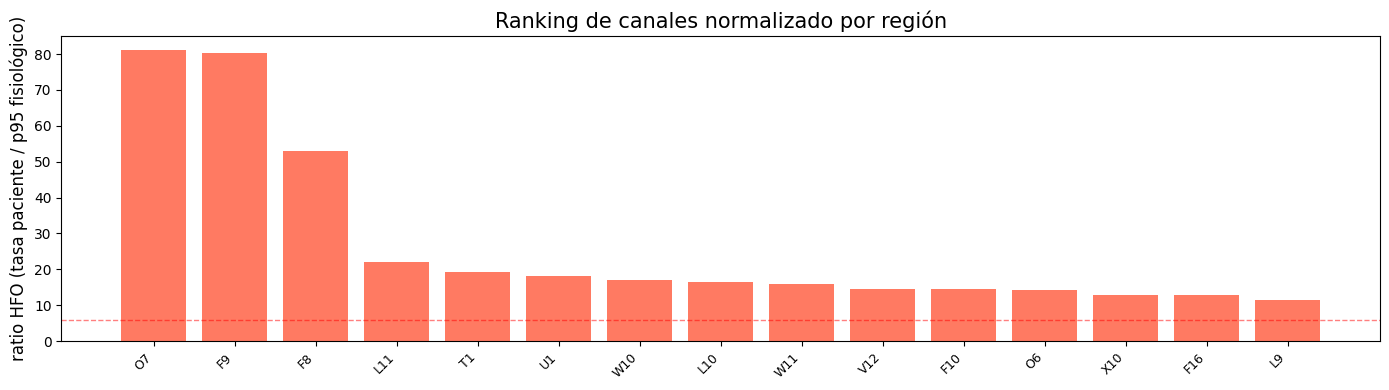

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

df_plot = df_rank[df_rank['ratio_HFO'].notna()].sort_values('ratio_HFO', ascending=False)
top = min(15, len(df_plot))
ratios  = df_plot['ratio_HFO'].iloc[:top]
colores = ['tomato' if p == True else 'seagreen' 
           for p in df_plot['patológico'].iloc[:top]]

ax.bar(range(top), ratios, color=colores, alpha=0.85)
ax.set_xticks(range(top))
ax.set_xticklabels(df_plot.index[:top], rotation=45, ha='right', fontsize=9)
ax.axhline(RATIO_UMBRAL, color='red', ls='--', lw=1, alpha=0.5)
ax.set_ylabel('ratio HFO (tasa paciente / p95 fisiológico)',fontsize=12)
ax.set_title('Ranking de canales normalizado por región', fontsize= 15)
plt.tight_layout()
plt.show()

### Se muestran los 15 primeros con mayor ratio HFO, si sale la barra verde, no se ha clasificado como patológico, aunque es conveniente revisarlo.

---
# HFO on spike --> onda lenta (alta amplitud, baja frecuencia) antes de una ráfaga HFO
#### Para cada HFO válido ya detectado, sin tener en cuenta la normalización, ver la señal cruda en una ventana justo antes de la ráfaga de HFO. Aplicamos filtro de en banda lenta (1-30 Hz), y compruebo si hay una deflexión grande, que sería la onda lenta del spike. Si la hay, ese HFO se marca como patológico con probabilidad muy muy alta.
## 1. Parámetros (ajustables si salen muchos o pocos)
#### Empezamos con una banda de 1-30 Hz para la onda lenta

In [ ]:
LOW_ONDA=1 #Hz
HIGH_ONDA=30

#Cogemos la ventana de antes del HFO, la onda lenta interictal típica dura entre 50-200 ms,
#así que con 220 ms de ventana previa capturamos la onda entera aunque empiece justo al límite.

VENTANA_ANTES_MS = 220 # ms antes del inicio del HFO detectado
VENTANA_DESPUES_MS = 0

UMBRAL_ONDA_FACTOR = 2

umbral = la onda lenta tiene que ser X veces el baseline lento del canal 
- si salen demasiados HFO --> subir umbral (a 4,5...)
- si salen muy pocos o ninguno --> bajar umbral

## 2. Calculamos baseline lento por canal
Filtramos toda la señal de cada canal en la banda lenta (1-30 Hz) y calculamos el percentil 90 del valor absoluto.
Usamos este baseline como referencia.

In [ ]:
def filtrar_lento(senal_1d,sfreq,low=LOW_ONDA, high=HIGH_ONDA, orden=4):
    nyq=sfreq/2
    b,a=butter(orden,[low/nyq,high/nyq], btype='band')
    return filtfilt(b, a, senal_1d)

ventana_antes_s = int(VENTANA_ANTES_MS *sfreq /1000) #muestras para los 220ms
ventana_despues_s = int(VENTANA_DESPUES_MS* sfreq / 1000)

baseline_lento = {} #por canal
for ci, nombre in enumerate(nombres):
    senal_lenta = filtrar_lento(datos[ci],sfreq)
    baseline_lento[nombre]=np.percentile(np.abs(senal_lenta),90)

print(f'Baseline calculado para {len(baseline_lento)} canales.')

Baseline calculado para 144 canales.


## 3. Detectamos posibles ondas lentas antes de cada HFO
Para cada HFO detectado, miramos los 220ms de antes, filtramos 1-30Hz, y vemos si el pico supera el baseline lento con el UMBRAL

In [ ]:
for ci, nombre in enumerate(nombres):
    for ev in resultados['ripple'].get(nombre, []):
        if not ev.get('valido'):
            continue

        ini_ventana = max(0, ev['inicio'] - ventana_antes_s)
        fin_ventana = ev['inicio']
        segmento = datos[ci, ini_ventana:fin_ventana]

        # segmento demasiado corto -> saltar
        if len(segmento) < 100:
            ev['ratio_onda_lenta'] = None
            ev['HFO_on_spike'] = False
            continue

        seg_lento = filtrar_lento(segmento, sfreq)
        pico_lento = np.max(np.abs(seg_lento))
        ratio_onda = pico_lento / (baseline_lento[nombre] + 1e-20)

        ev['ratio_onda_lenta'] = ratio_onda
        ev['HFO_on_spike'] = ratio_onda > UMBRAL_ONDA_FACTOR


n_on_spike = sum(
    1 for nombre in nombres
    for ev in resultados['ripple'].get(nombre, [])
    if ev.get('valido') and ev.get('HFO_on_spike'))

n_total_validos = sum(
    1 for nombre in nombres
    for ev in resultados['ripple'].get(nombre, [])
    if ev.get('valido'))

print(f'Número de HFOs con onda lenta (HFO on spike): {n_on_spike} de {n_total_validos} válidos.')
print(f'Porcentaje: {n_on_spike/n_total_validos*100:.1f}%' if n_total_validos > 0 else 'sin eventos') #por si acaso no se han detectado HFO válido

Número de HFOs con onda lenta (HFO on spike): 282 de 1346 válidos.
Porcentaje: 21.0%


In [ ]:
n_ratio_mayor1 = sum(
    1 for nombre in nombres
    for ev in resultados['ripple'].get(nombre, [])
    if ev.get('valido') and ev.get('ratio_onda_lenta') is not None
    and ev['ratio_onda_lenta'] > 1.0
)
print(f'eventos con ratio > 1.0: {n_ratio_mayor1}')

# ver la distribución completa de ratios
ratios_todos = [
    ev['ratio_onda_lenta']
    for nombre in nombres
    for ev in resultados['ripple'].get(nombre, [])
    if ev.get('valido') and ev.get('ratio_onda_lenta') is not None
]
print(f'ratio mínimo: {min(ratios_todos):.2f}')
print(f'ratio máximo: {max(ratios_todos):.2f}')
print(f'ratio mediana: {np.median(ratios_todos):.2f}')
print(f'ratio p90: {np.percentile(ratios_todos, 90):.2f}')

eventos con ratio > 1.0: 805
ratio mínimo: 0.19
ratio máximo: 20.18
ratio mediana: 1.14
ratio p90: 2.83


In [ ]:
# construyo df_spike y lo uno a df_rank
filas_spike = []
for nombre in nombres:
    evs = [e for e in resultados['ripple'].get(nombre, []) if e.get('valido')]
    n_spike = sum(1 for e in evs if e.get('HFO_on_spike'))
    n_total = len(evs)
    filas_spike.append({
        'canal': nombre,
        'n_HFO_on_spike': n_spike,
        'pct_on_spike': round(n_spike / n_total * 100, 1) if n_total > 0 else 0,
    })

df_spike = pd.DataFrame(filas_spike).set_index('canal')

for col in ['n_HFO_on_spike', 'pct_on_spike']:
    if col in df_rank.columns:
        df_rank.drop(columns=[col], inplace=True)

df_rank = df_rank.join(df_spike, how='left')
print(df_rank.columns.tolist())

['n_ripple', 'tasa_ripple', 'z_tasa_ripple', 'score', 'region', 'ATLAS', 'ref_p95', 'ratio_HFO', 'patológico', 'n_HFO_on_spike', 'pct_on_spike']


In [ ]:
cols = [c for c in ['tasa_ripple', 'n_HFO_on_spike', 'pct_on_spike', 'score']
        if c in df_rank.columns]
df_rank_mostrar = df_rank[cols].copy()
df_rank_mostrar.columns = ['HFOs/min', 'nº HFO on spike', '% HFO on spike', 'Score']
df_rank_mostrar = df_rank_mostrar.sort_values('nº HFO on spike', ascending=False).head(25).round(2)

df_rank_mostrar.style\
    .format('{:.1f}')\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '0px 20px')]}
    ])

,HFOs/min,nº HFO on spike,% HFO on spike,Score
canal,,,,
O7,6.5,40.0,56.3,3.4
U1,8.1,33.0,37.1,4.4
C4,6.8,17.0,23.0,3.6
T2,14.0,13.0,8.5,8.0
F9,4.0,13.0,29.5,1.9
O6,1.6,11.0,64.7,0.4
U2,3.0,10.0,30.3,1.3
W11,1.3,8.0,57.1,0.3
W1,1.7,6.0,31.6,0.5


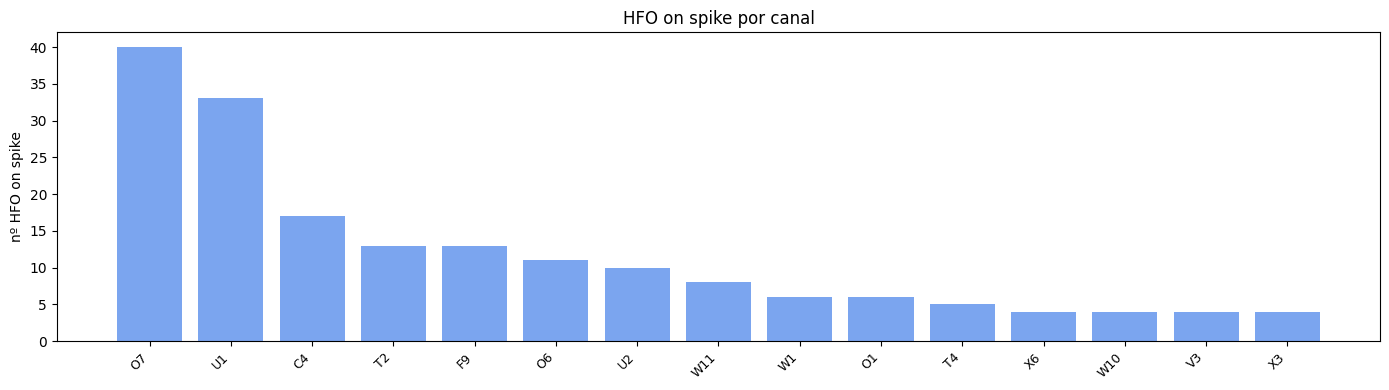

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

top = min(15, len(df_rank_mostrar))
valores = df_rank_mostrar['nº HFO on spike'].iloc[:top]
colores = ['cornflowerblue' if v > 0 else 'seagreen' for v in valores]

ax.bar(range(top), valores, color=colores, alpha=0.85)
ax.set_xticks(range(top))
ax.set_xticklabels(df_rank_mostrar.index[:top], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('nº HFO on spike')
ax.set_title('HFO on spike por canal')
plt.tight_layout()
plt.show()

## NORMALIZACIÓN + HFOs ON SPIKE (onda lenta previa al HFO)
### para el ranking usamos: score combinado = Ratio de HFOs x % HFOs on spike

In [ ]:
df_ambos = df_rank[df_rank['n_HFO_on_spike'] > 0].copy()

# nueva métrica combinada
df_ambos['score_combinado'] = df_ambos['ratio_HFO'] * (df_ambos['pct_on_spike'] / 100)

df_ambos = df_ambos.sort_values('score_combinado', ascending=False)

cols_ambos = [c for c in ['ratio_HFO', 'n_HFO_on_spike', 'pct_on_spike', 'score_combinado'] 
              if c in df_ambos.columns]

df_ambos_mostrar = df_ambos[cols_ambos].copy()
df_ambos_mostrar.columns = ['Ratio HFO', 'Nº HFO on spike', '% HFO on spike', 'Score combinado']

df_ambos_mostrar.style\
    .format('{:.2f}')\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '0px 20px')]}
    ])

,Ratio HFO,Nº HFO on spike,% HFO on spike,Score combinado
canal,,,,
O7,81.02,40.00,56.30,45.61
F9,80.33,13.00,29.50,23.70
O6,14.11,11.00,64.70,9.13
W11,15.98,8.00,57.10,9.12
F8,52.95,4.00,13.80,7.31
U1,18.06,33.00,37.10,6.70
O10,9.13,3.00,60.00,5.48
W10,17.12,4.00,26.70,4.57
V12,14.61,2.00,25.00,3.65


# RANKING FINAL CON LAS TRES MÉTRICAS

In [ ]:
# columna a: patológicos por normalización ordenados por ratio_HFO
col_a = df_rank[df_rank['patológico'] == True].sort_values('ratio_HFO', ascending=False)
lista_a = list(zip(col_a.index, col_a['ratio_HFO'].round(2)))

# columna b: canales con HFO on spike ordenados por n_HFO_on_spike
col_b = df_rank[df_rank['n_HFO_on_spike'] > 0].sort_values('n_HFO_on_spike', ascending=False)
lista_b = list(zip(col_b.index, col_b['n_HFO_on_spike'].round(2)))

# columna c: ambos criterios ordenados por score_combinado
lista_c = list(zip(df_ambos.index, df_ambos['score_combinado'].round(2)))

# número de filas lo domina la columna a
n_filas = len(lista_a)

# relleno con guiones donde no haya datos
def get_or_dash(lista, i):
    if i < len(lista):
        canal, valor = lista[i]
        return f'{canal} ({valor})'
    return '-'

filas_resumen = []
for i in range(n_filas):
    filas_resumen.append({
        'Normalización': get_or_dash(lista_a, i),
        'HFO on spike': get_or_dash(lista_b, i),
        'Normalización + HFO on spike': get_or_dash(lista_c, i),
    })

df_resumen = pd.DataFrame(filas_resumen, index=range(1, n_filas + 1))
df_resumen.index.name = 'Ranking'

df_resumen.style\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'center'), ('padding', '0px 20px')]}
    ])

,Normalización,HFO on spike,Normalización + HFO on spike
Ranking,,,
1,O7 (81.02),O7 (40),O7 (45.61)
2,F9 (80.33),U1 (33),F9 (23.7)
3,F8 (52.95),C4 (17),O6 (9.13)
4,L11 (21.91),T2 (13),W11 (9.12)
5,T1 (19.27),F9 (13),F8 (7.31)
6,U1 (18.06),O6 (11),U1 (6.7)
7,W10 (17.12),U2 (10),O10 (5.48)
8,L10 (16.43),W11 (8),W10 (4.57)
9,W11 (15.98),W1 (6),V12 (3.65)


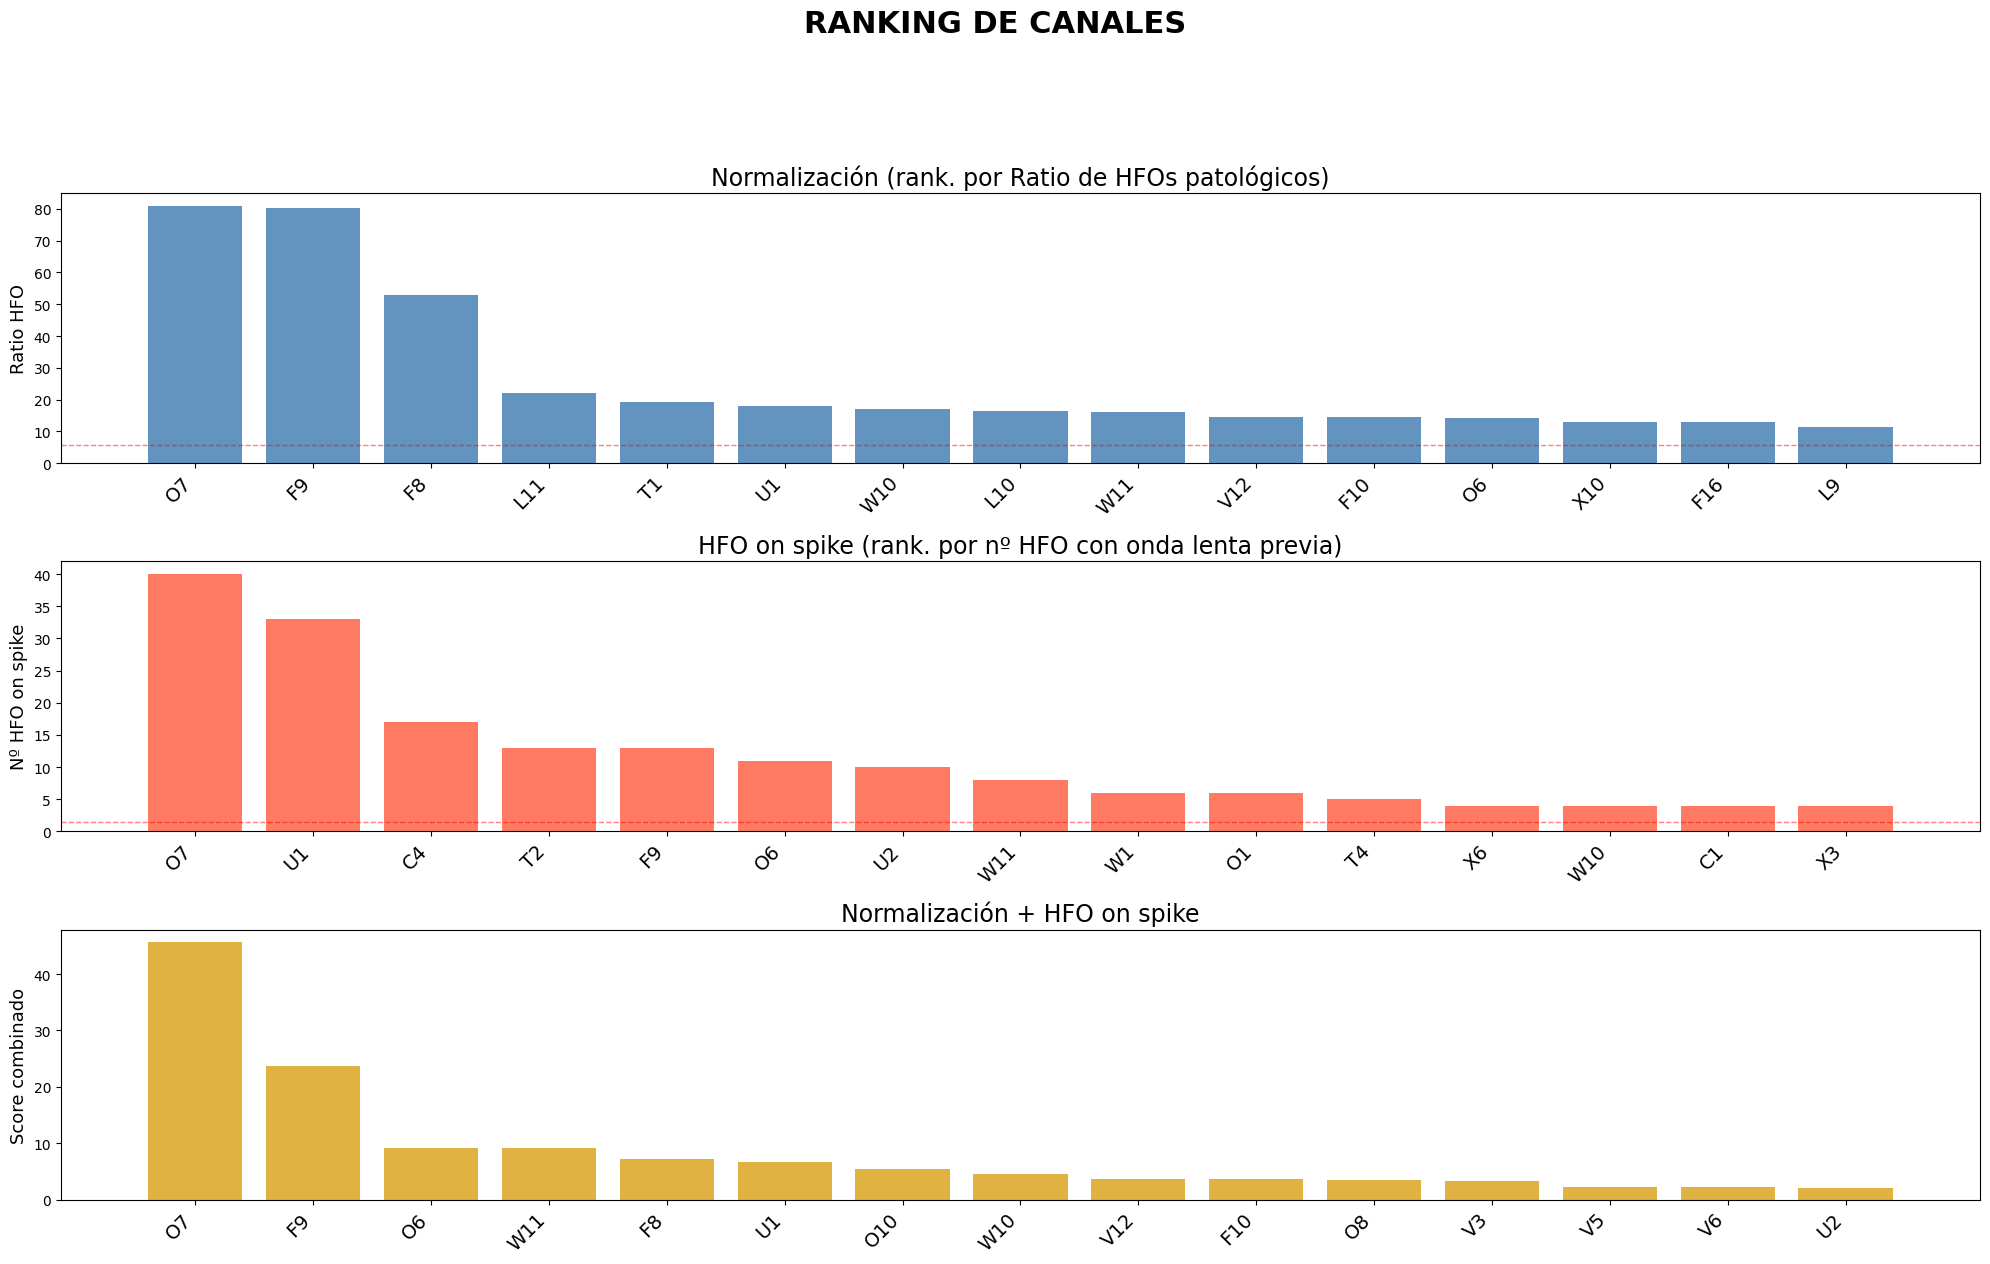

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(20, 12))

# NORMALIZACIÓN
col_a_plot = df_rank[df_rank['ratio_HFO'].notna()].sort_values('ratio_HFO', ascending=False)
top_a = min(15, len(col_a_plot))
axes[0].bar(range(top_a), col_a_plot['ratio_HFO'].iloc[:top_a], color='steelblue', alpha=0.85)
axes[0].axhline(RATIO_UMBRAL, color='red', ls='--', lw=1, alpha=0.5)
axes[0].set_xticks(range(top_a))
axes[0].set_xticklabels(col_a_plot.index[:top_a], rotation=45, ha='right', fontsize=14)
axes[0].set_ylabel('Ratio HFO', fontsize=13)
axes[0].set_title('Normalización (rank. por Ratio de HFOs patológicos)', fontsize=17)

# HFO ON SPIKE, CON ONDA LENTA PREVIA
col_b_plot = df_rank[df_rank['n_HFO_on_spike'] > 0].sort_values('n_HFO_on_spike', ascending=False)
top_b = min(15, len(col_b_plot))
umbral_spike = col_b_plot['n_HFO_on_spike'].median()
axes[1].bar(range(top_b), col_b_plot['n_HFO_on_spike'].iloc[:top_b], color='tomato', alpha=0.85)
axes[1].axhline(umbral_spike, color='red', ls='--', lw=1, alpha=0.5)
axes[1].set_xticks(range(top_b))
axes[1].set_xticklabels(col_b_plot.index[:top_b], rotation=45, ha='right', fontsize=14)
axes[1].set_ylabel('Nº HFO on spike', fontsize=13)
axes[1].set_title('HFO on spike (rank. por nº HFO con onda lenta previa)',fontsize=17)

# COMBINADOS
top_c = min(15, len(df_ambos))
umbral_combinado = df_ambos['score_combinado'].median()
axes[2].bar(range(top_c), df_ambos['score_combinado'].iloc[:top_c], color='goldenrod', alpha=0.85)
axes[2].set_xticks(range(top_c))
axes[2].set_xticklabels(df_ambos.index[:top_c], rotation=45, ha='right', fontsize=14)
axes[2].set_ylabel('Score combinado',fontsize=13)
axes[2].set_title('Normalización + HFO on spike',fontsize=17)

plt.suptitle('RANKING DE CANALES', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig(OUT_DIR, dpi=150, bbox_inches='tight')
plt.show()

# Visualización 3D

In [ ]:
loc_file = TSV_PATH

loc = pd.read_csv(loc_file, sep="\t")

print(loc.columns)
display(loc.head())

Index(['Channel', 'SCS', 'MNI', 'World',
       'Schaefer2018_100Parcels_17Networks_order',
       'Schaefer2018_100Parcels_17Networks_order_prob',
       'Schaefer2018_200Parcels_17Networks_order',
       'Schaefer2018_200Parcels_17Networks_order_prob',
       'Schaefer2018_400Parcels_17Networks_order',
       'Schaefer2018_400Parcels_17Networks_order_prob',
       'Schaefer2018_600Parcels_17Networks_order',
       'Schaefer2018_600Parcels_17Networks_order_prob', 'aal3', 'aal3_prob',
       'anatomy3', 'anatomy3_prob', 'cobra', 'cobra_prob', 'hammers',
       'hammers_prob', 'ibsr', 'ibsr_prob', 'julichbrain', 'julichbrain_prob',
       'lpba40', 'lpba40_prob', 'mori', 'mori_prob', 'neuromorphometrics',
       'neuromorphometrics_prob', 'thalamus', 'thalamus_prob', 'tissues_cat12',
       'tissues_cat12_prob', 'white_180654V:Desikan-Killiany',
       'white_180654V:Schaefer_100_17net', 'white_180654V:Schaefer_200_17net',
       'white_180654V:Schaefer_400_17net', 'white_180654V:Schaef

,Channel,SCS,MNI,World,Schaefer2018_100Parcels_17Networks_order,Schaefer2018_100Parcels_17Networks_order_prob,Schaefer2018_200Parcels_17Networks_order,Schaefer2018_200Parcels_17Networks_order_prob,Schaefer2018_400Parcels_17Networks_order,Schaefer2018_400Parcels_17Networks_order_prob,...,thalamus_prob,tissues_cat12,tissues_cat12_prob,white_180654V:Desikan-Killiany,white_180654V:Schaefer_100_17net,white_180654V:Schaefer_200_17net,white_180654V:Schaefer_400_17net,white_180654V:Schaefer_600_17net,white_180654V:HCP_MMP1,white_180654V:Destrieux
0,T1,"[-13.397,19.175,27.303]","[-21.841,-28.323,-16.651]","[-23.798,-17.206,7.714]",17Networks_LH_DefaultC_PHC_1,40%,17Networks_LH_DefaultC_PHC_1,40%,17Networks_LH_DefaultC_PHC_3,28%,...,NaN,White,75%,parahippocampal L,DefaultC_PHC_1 L,DefaultC_PHC_1 L,DefaultC_PHC_1 L,DefaultC_PHC_1 L,PreS L,G_oc-temp_med-Parahip L
1,T2,"[-13.424,22.673,27.391]","[-26.020,-27.123,-15.385]","[-27.294,-17.217,7.881]",17Networks_LH_DefaultC_PHC_1,1%,17Networks_LH_DefaultC_PHC_1,1%,17Networks_LH_DefaultC_PHC_2,1%,...,NaN,Gray,63%,NaN,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,H L,NaN
2,T3,"[-13.451,26.172,27.478]","[-29.759,-26.565,-14.860]","[-30.790,-17.228,8.048]",17Networks_LH_DefaultC_PHC_1,2%,17Networks_LH_DefaultC_PHC_1,2%,17Networks_LH_DefaultC_PHC_2,2%,...,NaN,Gray,86%,NaN,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,H L,NaN
3,T4,"[-13.478,29.671,27.566]","[-33.006,-26.840,-15.482]","[-34.286,-17.239,8.216]",17Networks_LH_DefaultC_PHC_1,9%,17Networks_LH_DefaultC_PHC_1,9%,17Networks_LH_DefaultC_PHC_2,9%,...,NaN,Gray,79%,fusiform L,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,Background+FreeSurfer_Defined_Medial_Wall L,H L,S_oc-temp_med_and_Lingual L
4,T5,"[-13.504,33.170,27.653]","[-36.067,-26.818,-15.737]","[-37.782,-17.250,8.383]",17Networks_LH_DefaultC_PHC_1,16%,17Networks_LH_DefaultC_PHC_1,16%,17Networks_LH_DefaultC_PHC_2,16%,...,NaN,Gray,83%,fusiform L,DefaultC_PHC_1 L,DefaultC_PHC_1 L,DefaultC_PHC_2 L,DefaultC_PHC_2 L,PHA3 L,S_oc-temp_med_and_Lingual L


In [ ]:
loc.columns = loc.columns.str.strip()

# Renombrar Channel -> Canal
loc = loc.rename(columns={"Channel": "Canal"})

# Ranking
rank = df_rank.copy()

if "Canal" not in rank.columns:
    rank = rank.reset_index()

rank.columns = rank.columns.str.strip()

if "canal" in rank.columns:
    rank = rank.rename(columns={"canal": "Canal"})

if "Channel" in rank.columns:
    rank = rank.rename(columns={"Channel": "Canal"})

# Unir ranking + MNI

rank_mni = rank.merge(
    loc[["Canal", "MNI"]],
    on="Canal",
    how="left"
)


# Top 25 por ratio_HFO

top25 = rank_mni.sort_values("ratio_HFO", ascending=False).head(25).copy()

# Separar coordenadas de la columna MNI en x, y, z
def parse_mni(value):
    if pd.isna(value):
        return pd.Series([None, None, None])

    value = str(value).strip()
    coords = ast.literal_eval(value)

    return pd.Series([coords[0], coords[1], coords[2]])

top25[["x", "y", "z"]] = top25["MNI"].apply(parse_mni)

# Excel
excel_3d = top25[["Canal", "x", "y", "z", "ratio_HFO"]].copy()
excel_3d = excel_3d.rename(columns={"ratio_HFO": "score"})

excel_3d.to_excel(out_file, index=False)

print("Guardado en:")
print(out_file)

display(excel_3d)

Guardado en:
C:\Users\Usuario\Documents\FILTRO SEEG\PACIENTE_1\resultados\Paciente_1_top25_HFO.xlsx


,Canal,x,y,z,score
3,O7,-21.465,-87.372,6.316,81.019399
5,F9,-42.206,-74.018,-2.873,80.334728
10,F8,-43.644,-70.740,-3.090,52.947889
17,L11,-21.014,-105.140,-5.863,21.909471
4,T1,-21.841,-28.323,-16.651,19.27222
1,U1,-25.560,-42.866,-15.802,18.055027
15,W10,-39.146,-65.604,4.897,17.116774
28,L10,-20.932,-101.718,-5.660,16.432103
16,W11,-42.416,-64.985,6.794,15.975656
30,V12,-46.328,-82.328,18.371,14.606314


In [ ]:
import plotly.graph_objects as go
import os
import nibabel as nib
import numpy as np
import pandas as pd
import webbrowser
from nilearn.datasets import fetch_icbm152_2009
from nilearn.masking import compute_brain_mask
from skimage import measure
from IPython.display import display, HTML

# LEER CONTACTOS HFO
df = pd.read_excel(file_3d)
coords = df[["x", "y", "z"]].values
scores = df["score"].values
labels = df["Canal"].tolist()

# CEREBRO MNI GENÉRICO: plantilla
mni = fetch_icbm152_2009()
img_mni = nib.load(mni['t1'])
data_mni = img_mni.get_fdata()

brain_mask = compute_brain_mask(img_mni)
mask = brain_mask.get_fdata()
brain = np.nan_to_num(data_mni * mask)
brain = (brain - brain.min()) / brain.max()

# Reducir un poco la resolución de la malla para acelerar la carga en el navegador
verts, faces, _, _ = measure.marching_cubes(brain[::2, ::2, ::2], level=0.12)
verts = verts * 2  # Reescalamos por la reducción de resolución
verts_mni = nib.affines.apply_affine(img_mni.affine, verts)

fig_soft = go.Figure()

# Malla del Cerebro 3D
fig_soft.add_trace(
    go.Mesh3d(
        x=verts_mni[:, 0],
        y=verts_mni[:, 1],
        z=verts_mni[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        opacity=0.15,
        color="gray",
        hoverinfo="skip",
        showlegend=False
    )
)

colorscale_hot = [
    [0.00, "blue"],
    [0.25, "cyan"],
    [0.50, "yellow"],
    [0.75, "orange"],
    [1.00, "red"]
]

for idx, (size, opacity) in enumerate([(18, 0.10), (11, 0.22), (5, 0.95)]):
    mostrar_colorbar = True if size == 5 else False
    fig_soft.add_trace(
        go.Scatter3d(
            x=coords[:, 0],
            y=coords[:, 1],
            z=coords[:, 2],
            mode="markers",
            marker=dict(
                size=size,
                color=scores,
                colorscale=colorscale_hot,
                cmin=40,
                cmax=max(scores.max(), 41),
                opacity=opacity,
                line=dict(width=0),
                showscale=mostrar_colorbar,
                colorbar=dict(
                    title="ratio_HFO",
                    thickness=18,
                    len=0.65,
                    x=0.85
                ) if mostrar_colorbar else None
            ),
            hoverinfo="skip",
            showlegend=False
        )
    )

fig_soft.add_trace(go.Scatter3d(   
    x=coords[:, 0],
    y=coords[:, 1],
    z=coords[:, 2] + 2,            # +2 para que flote ligeramente encima del punto
    mode="text",
    text=labels,
    textposition="middle center",
    textfont=dict(size=10, color="black"),
    hoverinfo="skip",
    showlegend=False
))

fig_soft.update_layout(
    title="Mapa HFO",
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode="data",
        camera=dict(eye=dict(x=1.8, y=1.8, z=1.2))
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

# Guardar primero
ruta_fija = os.path.normpath(html_soft)
fig_soft.write_html(ruta_fija, include_plotlyjs="cdn")
print("Guardado en:")
print(ruta_fija)

# Abrir en el navegador predeterminado
webbrowser.open("file:///" + ruta_fija)

display(HTML(f'<a href="file:///{ruta_fija}" target="_blank"> Haz clic aquí para abrir el cerebro 3D en el navegador</a>'))


[fetch_icbm152_2009] Dataset found in C:\Users\Usuario\nilearn_data\icbm152_2009

Guardado en:
C:\Users\Usuario\Documents\FILTRO SEEG\PACIENTE_1\resultados\Paciente_1_cerebro3D_plantilla.html


# HFOs EN LA RM DEL PACIENTE

https://github.com/rordenlab/dcm2niix/releases/tag/v1.0.20260416
descargar el ...win.zip y extraer, meter ruta en la línea resultado = subprocess.run(
        [r"C:\Users\Usuario\Downloads\dcm2niix_win\dcm2niix.exe", "-z", "y", "-o", nifti_dir, DICOM_DIR]

In [ ]:
import os
import glob
import subprocess
import webbrowser
import nibabel as nib
import numpy as np
import pandas as pd
from nilearn.masking import compute_brain_mask
from skimage import measure
import plotly.graph_objects as go
from IPython.display import display, HTML

# Convertir DICOM a NIfTI con dcm2niix
nifti_dir  = os.path.join(out_dir, "nifti")
os.makedirs(nifti_dir, exist_ok=True)
nifti_file_list = glob.glob(os.path.join(nifti_dir, "*.nii*"))

if not nifti_file_list:
    resultado = subprocess.run(
        [r"C:\Users\Usuario\Downloads\dcm2niix_win\dcm2niix.exe", "-z", "y", "-o", nifti_dir, DICOM_DIR],
        capture_output=True, text=True
    )
    print(resultado.stdout)
    if resultado.returncode != 0:
        print("ERROR:", resultado.stderr)
        raise RuntimeError("Conversión DICOM fallida.")
    nifti_file_list = glob.glob(os.path.join(nifti_dir, "*.nii*"))
    print(f"Conversión completada. Archivos: {len(nifti_file_list)}")
else:
    print(f"NIfTI ya existe, usando el existente")

# Coger el NIfTI más grande (suele ser la T1)
nifti_file = max(nifti_file_list, key=os.path.getsize)
print(f"Usando: {os.path.basename(nifti_file)}")

# Leer RM NIfTI 
img = nib.load(nifti_file)
data = img.get_fdata()

brain_mask = compute_brain_mask(img)
mask = brain_mask.get_fdata()
brain = np.nan_to_num(data * mask)
brain = (brain - brain.min()) / brain.max()

print(f"Rango del volumen: min={brain.min():.3f}, max={brain.max():.3f}")
print(f"Percentil 10: {np.percentile(brain[brain>0], 10):.3f}")
print(f"Percentil 20: {np.percentile(brain[brain>0], 20):.3f}")
print(f"Percentil 30: {np.percentile(brain[brain>0], 30):.3f}")

# Nivel = percentil 15 de los vóxeles no nulos (funciona con cualquier RM)
level = float(np.percentile(brain[brain > 0], 15))
print(f"Usando level={level:.3f}")

# Superficie 3D 
verts, faces, _, _ = measure.marching_cubes(brain, level=level)
verts_world = nib.affines.apply_affine(img.affine, verts)
print(f"Superficie generada: {len(verts)} vértices")

# Leer contactos HFO 
df_3d= pd.read_excel(file_3d)
coords = df_3d[["x", "y", "z"]].values
scores = df_3d["score"].values
labels = df_3d["Canal"].tolist()

fig_rm = go.Figure()

fig_rm.add_trace(go.Mesh3d(
    x=verts_world[:, 0], y=verts_world[:, 1], z=verts_world[:, 2],
    i=faces[:, 0], j=faces[:, 1], k=faces[:, 2],
    opacity=0.12, color="lightgray",
    hoverinfo="skip", showlegend=False
))

colorscale_hot = [
    [0.00, "blue"], [0.25, "cyan"], [0.50, "yellow"],
    [0.75, "orange"], [1.00, "red"]
]

for size, opacity in [(18, 0.10), (11, 0.22), (5, 0.95)]:
    fig_rm.add_trace(go.Scatter3d(
        x=coords[:, 0], y=coords[:, 1], z=coords[:, 2],
        mode="markers",
        marker=dict(
            size=size, color=scores, colorscale=colorscale_hot,
            cmin=40, cmax=max(scores.max(), 41),
            opacity=opacity, line=dict(width=0),
            showscale=(size == 5),
            colorbar=dict(title="ratio_HFO", thickness=18, len=0.65, x=0.85) if size == 5 else None
        ),
        hoverinfo="skip", showlegend=False
    ))

fig_rm.add_trace(go.Scatter3d(
    x=coords[:,0],
    y=coords[:,1],
    z=coords[:,2] + 2,
    mode="text",
    text=labels,
    textposition="middle center",
    textfont=dict(size=10, color="black"),
    hoverinfo="skip",
    showlegend=False
))

fig_rm.update_layout(
    title=f"{PACIENTE} – HFOs sobre RM del paciente",
    scene=dict(
        xaxis_visible=False, yaxis_visible=False, zaxis_visible=False,
        aspectmode="data", camera=dict(eye=dict(x=1.8, y=1.8, z=1.2))
    ),
    margin=dict(l=0, r=0, t=40, b=0)
)

# Guardar y abrir
html_rm = os.path.join(out_dir, f"{PACIENTE}_RM_HFO.html")
ruta_rm = os.path.normpath(html_rm)
fig_rm.write_html(ruta_rm, include_plotlyjs="cdn")
print("Guardado en:", ruta_rm)

webbrowser.open("file:///" + ruta_rm)
display(HTML(f'<a href="file:///{ruta_rm}" target="_blank"> Haz clic aquí para abrir la RM con HFOs</a>'))

Convirtiendo DICOM a NIfTI... (puede tardar 1-2 min)
Chris Rorden's dcm2niiX version v1.0.20260416  (JP2:OpenJPEG) (JP-LS:CharLS) MSC1944  (64-bit Windows)
Found 176 DICOM file(s)
Convert 176 DICOM as C:\Users\Usuario\Documents\FILTRO SEEG\PACIENTE_1\resultados\nifti\11230000_t1_mprage_sag_p2_iso_20240119125739_5 (256x256x176x1)
Conversion required 2.476000 seconds.

Conversión completada. Archivos: 1
Usando: 11230000_t1_mprage_sag_p2_iso_20240119125739_5.nii.gz
Rango del volumen: min=0.000, max=1.000
Percentil 10: 0.051
Percentil 20: 0.106
Percentil 30: 0.136
Usando level=0.080
Superficie generada: 516468 vértices
Guardado en: C:\Users\Usuario\Documents\FILTRO SEEG\PACIENTE_1\resultados\Paciente_1_RM_HFO.html
